#Bird Trajectory Prediction with an RNN

In [13]:
!pip -q install haversine
!pip -q install torch
!pip -q install gdown

# Visualisation

This dataset contains GPS tracking data for three birds: Eric, Nico, and Sanne.
Each row represents a recorded position at a specific timestamp, including:


* Latitude & Longitude – geographic position

* Altitude – flight height

* Speed (2D) – ground speed

* Direction – movement heading

* Date & Time – timestamp of observation

Downloading...
From: https://drive.google.com/uc?id=1eXuZX8YtOtlEwzBQlYetGkRDR6DCejSZ
To: /content/bird_tracking.csv
100%|██████████| 5.67M/5.67M [00:00<00:00, 41.7MB/s]


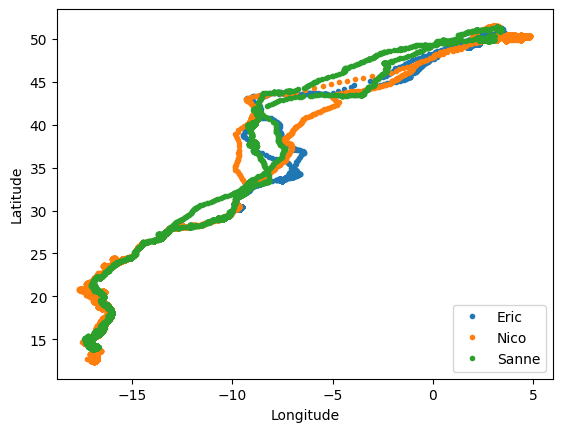

In [14]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt

file_id = "1eXuZX8YtOtlEwzBQlYetGkRDR6DCejSZ"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "bird_tracking.csv", quiet=False)
birddata = pd.read_csv('bird_tracking.csv')

bird_names = pd.unique(birddata.bird_name)

for bird_name in bird_names:
	ix = birddata.bird_name == bird_name
	x,y = birddata.longitude[ix], birddata.latitude[ix]
	plt.plot(x,y,".", label=bird_name)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="lower right")
plt.show()

## Data Preprocessing

This step prepares the raw GPS data so it can be used to train the RNN.

First, we convert the timestamps into proper datetime format and extract simple time features: **hour, day, and month**. These help the model understand when movements happen.

Next, missing values in **direction** and **speed** are filled using interpolation for each bird separately. This keeps the movement smooth and avoids gaps.

We also add two new movement features:

* **step_distance** – distance between consecutive GPS points
* **bearing** – direction of movement in degrees

After that, all selected features are scaled using **MinMax scaling**. The scaler is fit only on the training bird and reused for validation and test data.

Finally, we create sequences of length **10 timesteps**.
Each sequence is used to predict the **next latitude and longitude**.

The data is split by bird:

* **Eric** → training
* **Nico** → validation
* **Sanne** → testing


In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from math import radians, sin, cos, atan2
from haversine import haversine, Unit

def add_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("date_time").reset_index(drop=True)
    coords = list(zip(g["latitude"].astype(float), g["longitude"].astype(float)))

    g["step_distance"] = [0.0] + [
        haversine(coords[i-1], coords[i], unit=Unit.KILOMETERS) for i in range(1, len(coords))
    ]

    bearings = [0.0]
    for i in range(1, len(coords)):
        lat1, lon1 = map(radians, coords[i-1])
        lat2, lon2 = map(radians, coords[i])
        dlon = lon2 - lon1
        x = sin(dlon) * cos(lat2)
        y = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
        bearings.append((atan2(x, y) * 180 / np.pi + 360) % 360)
    g["bearing"] = bearings
    return g

def make_xy(arr: np.ndarray, seq_len: int, y_idx: list[int]):
    X = np.array([arr[i:i+seq_len] for i in range(len(arr) - seq_len)])
    y = np.array([arr[i+seq_len, y_idx] for i in range(len(arr) - seq_len)])
    return X, y

def preprocess_and_create_sequences(df: pd.DataFrame, seq_len=10, scaler_X=None, scaler_y=None):
    df = df.copy()
    df["date_time"] = pd.to_datetime(df["date_time"])

    df["hour"]  = df["date_time"].dt.hour
    df["day"]   = df["date_time"].dt.day
    df["month"] = df["date_time"].dt.month

    df = df.sort_values(["bird_name", "date_time"]).reset_index(drop=True)

    df["direction"] = df.groupby("bird_name")["direction"].transform(lambda x: x.interpolate())
    df["speed_2d"]  = df.groupby("bird_name")["speed_2d"].transform(lambda x: x.interpolate())

    df = df.groupby("bird_name", group_keys=False).apply(add_features, include_groups=False)

    features = [
        "latitude","longitude","altitude","direction",
        "speed_2d","step_distance","bearing","hour","day","month"
    ]
    y_idx = [features.index("latitude"), features.index("longitude")]

    if scaler_X is None:
        scaler_X = MinMaxScaler().fit(df[features])
    df[features] = scaler_X.transform(df[features])

    X, y = make_xy(df[features].values, seq_len, y_idx)

    if scaler_y is None:
        scaler_y = MinMaxScaler().fit(y)
    y = scaler_y.transform(y)

    return X, y, df, features, scaler_X, scaler_y


SEQ_LEN = 10
df_eric  = birddata[birddata.bird_name == "Eric"].copy()
df_nico  = birddata[birddata.bird_name == "Nico"].copy()
df_sanne = birddata[birddata.bird_name == "Sanne"].copy()

X_train, y_train, df_train, features, scaler_X, scaler_y = preprocess_and_create_sequences(df_eric,  seq_len=SEQ_LEN)
X_val,   y_val,   df_val,   _,        _,        _        = preprocess_and_create_sequences(df_nico,  seq_len=SEQ_LEN, scaler_X=scaler_X, scaler_y=scaler_y)
X_test,  y_test,  df_test,  _,        _,        _        = preprocess_and_create_sequences(df_sanne, seq_len=SEQ_LEN, scaler_X=scaler_X, scaler_y=scaler_y)

print("Train (Eric)")
print(f"  Sequences: {X_train.shape[0]}")

print("Val (Nico)")
print(f"  Sequences: {X_val.shape[0]}")

print("Test (Sanne)")
print(f"  Sequences: {X_test.shape[0]}")

Train (Eric)
  Sequences: 19785
Val (Nico)
  Sequences: 21111
Test (Sanne)
  Sequences: 20994


#Training the RNN

### Model

The model is a simple **RNN** with:

* 2 recurrent layers
* dropout to reduce overfitting
* a final linear layer that predicts the next **latitude and longitude**

It looks at a sequence of past points and uses the **last timestep** to predict the next position.

### Data Loading
The training and validation data are converted to PyTorch tensors and loaded in batches. Training data is shuffled, validation data is not.

### Training
We train the model using MSE loss and the Adam optimizer. Gradients are clipped to prevent unstable updates during RNN training.

### Validation and Early Stopping
After each epoch, we check the validation loss.
If it improves, we save the model.
If it does not improve for a few epochs (`patience=5`), training stops early to avoid overfitting.

### Final Model
At the end, we load the best saved model and return it for evaluation or testing.


In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=2, num_layers=2, dropout=0.3):
        super().__init__()
        self.rnn = nn.RNN(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(self.drop(out[:, -1, :]))


def train_rnn(
    X_train, y_train,
    X_val, y_val,
    hidden_dim=64, num_layers=2, dropout=0.3,
    batch_size=32, epochs=20, lr=1e-3, weight_decay=1e-4,
    patience=5, save_path="best_rnn.pth"
):
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train, dtype=torch.float32)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False
    )

    model = RNNModel(
        input_dim=X_train.shape[2],
        hidden_dim=hidden_dim,
        output_dim=y_train.shape[1],
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    bad = 0

    for epoch in range(1, epochs + 1):
        model.train()
        tr_sum = 0.0
        tr_n = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_sum += loss.item() * Xb.size(0)
            tr_n += Xb.size(0)
        train_loss = tr_sum / max(tr_n, 1)

        model.eval()
        va_sum = 0.0
        va_n = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                va_sum += crit(model(Xb), yb).item() * Xb.size(0)
                va_n += Xb.size(0)
        val_loss = va_sum / max(va_n, 1)

        print(f"Epoch {epoch:3d}/{epochs} | train {train_loss:.6f} | val {val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            bad = 0
            torch.save(model.state_dict(), save_path)
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping (best val_loss={best_val:.6f})")
                break

    model.load_state_dict(torch.load(save_path, map_location=device))
    return model


model = train_rnn(
    X_train, y_train,
    X_val, y_val,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    batch_size=32,
    epochs=20,
    lr=1e-3,
    patience=5,
    save_path="best_rnn.pth"
)

Epoch   1/20 | train 0.012765 | val 0.007097
Epoch   2/20 | train 0.004756 | val 0.003634
Epoch   3/20 | train 0.003417 | val 0.009338
Epoch   4/20 | train 0.002904 | val 0.027411
Epoch   5/20 | train 0.002525 | val 0.047152
Epoch   6/20 | train 0.002355 | val 0.059101
Epoch   7/20 | train 0.002187 | val 0.072142
Early stopping (best val_loss=0.003634)


#Testing

This code checks the trained RNN predicts the bird’s next GPS position on the **test set**.

### Load test data + model

* Wraps `X_test` and `y_test` into a `DataLoader` (no shuffling).
* Rebuilds the model, loads weights from `best_rnn.pth`, and switches to `eval()` mode.

### Convert predictions back to real coordinates

The model outputs scaled values, so we convert them back to real units:

* `scaler_y.inverse_transform(...)` turns predicted targets back into real latitude/longitude change.
* We also unscale the **last input point** from each sequence, so we know the previous real GPS location.
* Final predicted point = **previous point + predicted change**
  Same for the true next point.

### Metrics + baseline

* **RMSE** and **MAE** for the model (in lat/lon units)
* A simple baseline: **“next position = previous position”**
  This baseline helps show if the model is actually doing better than just guessing no movement.

### Plot

It plots up to 200 points of the test trajectory:

* **Actual** path
* **Predicted** path
* **Baseline** path (dashed)


TEST RESULTS (lat/lon units)
RMSE: 0.082102 | MAE: 0.056810
Baseline RMSE: 0.631015 | Baseline MAE: 0.590821


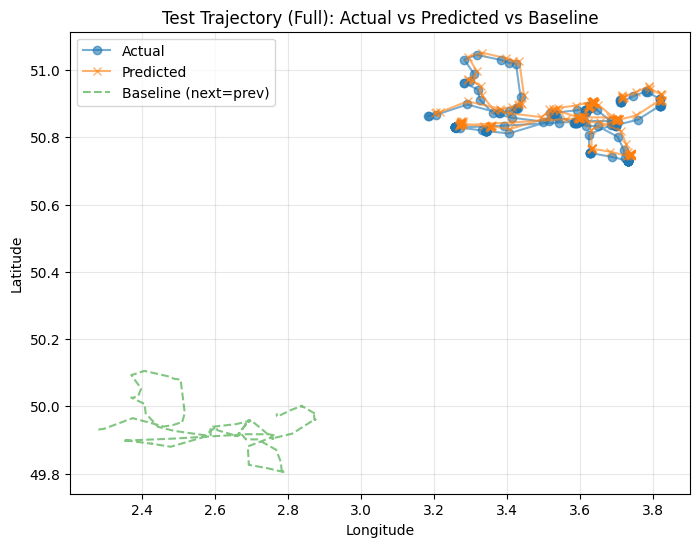

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

def test_displacement(
    model_path,
    model_class,
    model_params,
    X_test, y_test,
    scaler_y, scaler_X,
    features,
    device,
    batch_size=32,
    plot_samples=200
):
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False
    )

    model = model_class(**model_params).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    lat_idx = features.index("latitude")
    lon_idx = features.index("longitude")

    preds_abs, actuals_abs, base_abs = [], [], []

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.cpu().numpy()

            pred_scaled = model(Xb).cpu().numpy()
            pred_delta = scaler_y.inverse_transform(pred_scaled)
            true_delta = scaler_y.inverse_transform(yb)

            X_last_scaled = Xb[:, -1, :].cpu().numpy()
            X_last_abs_full = scaler_X.inverse_transform(X_last_scaled)
            prev_abs = X_last_abs_full[:, [lat_idx, lon_idx]]

            preds_abs.append(prev_abs + pred_delta)
            actuals_abs.append(prev_abs + true_delta)
            base_abs.append(prev_abs)

    preds = np.vstack(preds_abs)
    actuals = np.vstack(actuals_abs)
    baseline = np.vstack(base_abs)

    rmse = float(np.sqrt(np.mean((preds - actuals) ** 2)))
    mae  = float(np.mean(np.abs(preds - actuals)))

    base_rmse = float(np.sqrt(np.mean((baseline - actuals) ** 2)))
    base_mae  = float(np.mean(np.abs(baseline - actuals)))

    print("TEST RESULTS (lat/lon units)")
    print(f"RMSE: {rmse:.6f} | MAE: {mae:.6f}")
    print(f"Baseline RMSE: {base_rmse:.6f} | Baseline MAE: {base_mae:.6f}")



    n = min(plot_samples, len(actuals))
    plt.figure(figsize=(8,6))
    plt.plot(actuals[:n, 1], actuals[:n, 0], label="Actual", marker="o", alpha=0.6)
    plt.plot(preds[:n, 1],   preds[:n, 0],   label="Predicted", marker="x", alpha=0.6)
    plt.plot(baseline[:n, 1], baseline[:n, 0], label="Baseline (next=prev)", linestyle="--", alpha=0.6)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Test Trajectory (Full): Actual vs Predicted vs Baseline")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return {
        "rmse": rmse,
        "mae": mae,
        "baseline_rmse": base_rmse,
        "baseline_mae": base_mae,
    }


model_params = {
    "input_dim": X_train.shape[2],
    "hidden_dim": 64,
    "output_dim": 2,
    "num_layers": 2,
    "dropout": 0.3
}

results = test_displacement(
    model_path="best_rnn.pth",
    model_class=RNNModel,
    model_params=model_params,
    X_test=X_test,
    y_test=y_test,
    scaler_y=scaler_y,
    scaler_X=scaler_X,
    features=features,
    device=device,
    batch_size=32,
    plot_samples=200
)
